## Import och Databehandling för lufttemperaturdata från SMHI
*E. Haaf (Chalmers), 2026*

Detta skript läser lufttemperaturdata direkt från SMHI:s CSV-format. Skriptet:

1. Tolkar SMHI:s CSV-format med metadata-rader i början och extraherar relevant data
2. Hanterar kvalitetskoder och behåller värden med kvalitetskod G eller Y
3. Exporterar till en renare CSV-fil (temp_data.csv) i samma mapp som inmatningsfilen
4. Visualisering

### 0. Importera bibliotek

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

### 1. Tolka SMHI's csv format

In [2]:
# Läs lufttemperaturdata från SMHI CSV-format

# Ange filsökvägen till SMHI CSV-filen
file_path = "../data/smhi-opendata_2_86420.csv"  # Ange filsökvägen

# Hitta raden med kolumnnamn (börjar med "Från Datum Tid")
# SMHI-filen innehåller metadatablock i början före själva datatabellen
skip_rows = 0
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if 'Från Datum Tid' in line:  # Hitta header-raden
            skip_rows = i
            break

# Läs CSV-filen och hoppa över metadata-raderna
df = pd.read_csv(file_path, skiprows=skip_rows, sep=';')  # Läs CSV med semikolon som separator

# Välj relevanta kolumner från SMHI-filen
df = df[['Representativt dygn', 'Lufttemperatur', 'Kvalitet']].copy()  # Välj de kolumner vi behöver

### 2. Hantering av kvalitetskoder

In [3]:
# Konvertera temperaturkolumnen till numeriskt format
df['Lufttemperatur'] = pd.to_numeric(df['Lufttemperatur'], errors='coerce')  # Ogiltiga värden blir NaN

# För denna SMHI-fil förekommer främst kvalitetskoderna G och Y
# Behåll båda och sätt övriga kvalitetskoder till NaN
df.loc[~df['Kvalitet'].isin(['G', 'Y']), 'Lufttemperatur'] = float('nan')  # Markera övriga kvaliteter som NaN

# Radera Kvalitet-kolumnen efter kvalitetskontrollen
df = df.drop('Kvalitet', axis=1)  # Ta bort den tillfälliga kolumnen

### 3. Formatering och export

In [4]:
# Byt namn på kolumner till förenklat format
df.columns = ['Datum', 'Temp']  # Datum: representativt dygn, Temp: lufttemperatur i celsius

# Konvertera Datum till datetime-format
df['Datum'] = pd.to_datetime(df['Datum'])  # Konvertera tidssträngar till datetime

# Spara som CSV i samma mapp som inmatningsfilen
output_directory = os.path.dirname(file_path)  # Använd samma katalog som inmatningsfilen
output_path = os.path.join(output_directory, 'temp_data_km.csv')  # Skapa sökväg till utdatafilen

df.to_csv(output_path, index=False)  # Exportera till CSV

print(f"Behandlad lufttemperaturdata har sparats till {output_path}")  # Bekräfta att filen sparades
print(df.head())

Behandlad lufttemperaturdata har sparats till ../data\temp_data_km.csv
       Datum  Temp
0 1995-12-17  -1.5
1 1995-12-18  -4.2
2 1995-12-19  -7.1
3 1995-12-20 -10.3
4 1995-12-21  -8.5


### 4. Visualisering

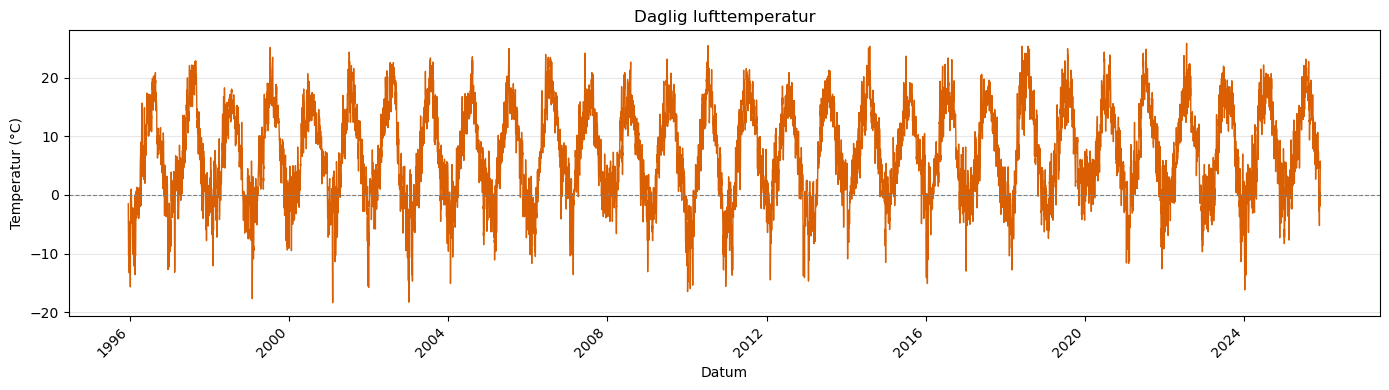

In [5]:
# Skapa ett linjediagram av den slutliga temperaturserien
fig, ax = plt.subplots(figsize=(14, 4))

# Rita daglig lufttemperatur som linje
ax.plot(df['Datum'], df['Temp'], linewidth=1.0, color='#d95f02')

# Lägg till en referenslinje vid noll grader
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Lägg till rubrik och axel-etiketter
ax.set_title('Daglig lufttemperatur')
ax.set_xlabel('Datum')
ax.set_ylabel('Temperatur (°C)')

# Förbättra läsbarheten i figuren
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Visa figuren utan att blockera kerneln
plt.show(block=False)
plt.close(fig)